In [1]:
# Импорт библиотек для работы с данными
import pandas as pd # для работы с табличными данными
import numpy as np # для математических операций
import openpyxl # для работы с Excel файлами

# Импорт библиотек для визуализации
import seaborn as sns # для статистической графики
import matplotlib.pyplot as plt # для построения графиков
import matplotlib.dates as mdates # для работы с датами на графиках

# Импорт модулей машинного обучения из scikit-learn
from sklearn.model_selection import train_test_split # для разделения данных на train/test
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error # метрики оценки модели
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder # предобработка данных
from statsmodels. tsa.stattools import grangercausalitytests # тест причинности Грейнджера для временных рядов

# Импорт конкретных алгоритмов и методов ML
from sklearn.ensemble import RandomForestRegressor # алгоритм случайного леса для регрессии
from sklearn.pipeline import Pipeline # для создания конвейеров обработки данных
from sklearn.model_selection import GridSearchCV # для подбора гиперпараметров
from sklearn.feature_selection import RFE # рекурсивное исключение признаков

# Установка стиля графиков (стиль FiveThirtyEight)
plt.style.use('fivethirtyeight')

# Импорт модулей для работы с датами и временем
import datetime
from datetime import date, datetime, timedelta

# Отключение предупреждений для чистоты вывода
import warnings
warnings.filterwarnings('ignore')

# Функции

In [2]:
# Функция для отображения графиков
def draw_result(y_test, pred, model):

    """
    Визуализирует сравнение фактических и прогнозных значений
    
    Параметры:
    y_test - фактические значения (с датами в индексе)
    pred - прогнозные значения
    model - название модели для заголовка графика
    """
    date_lst = [pd.to_datetime(dat).date() for dat in y_test.index] # Преобразуем индекс дат в объекты date для корректного отображения
    
    fig, ax = plt.subplots(figsize=(17,5)) # Создаем график с заданным размером
    
    # Строим линии: зеленая - факт, красная - прогноз
    ax.plot(date_lst, y_test, color='green', linewidth=3)
    ax.plot(date_lst, pred, color='red', linewidth=3)
    # Настраиваем легенду и заголовок
    plt.legend(["Фактическое значение", "Прогноз"], loc="upper right")
    plt.title(model)
    # Устанавливаем отметки по месяцам на оси X
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
    
    # Настраиваем отображение дат
    ax.tick_params(axis='x', labelsize=9)
    plt.gcf().autofmt_xdate() # автоматический формат дат
    plt.xticks(rotation = 0) # Поворачиваем надписи
   
    
# Функция для вывода ошибок RMSE и MAE
def rmse(fact, pred):
    """
    Вычисляет среднеквадратичную ошибку вручную
    
    Параметры:
    fact - фактические значения
    pred - прогнозные значения
    
    Возвращает:
    rmse_val - значение RMSE, округленное до 3 знаков
    """
    diff = pred - fact # разница между прогнозом и фактом
    different_squares = diff * diff # квадраты разниц
    mean_diff = different_squares.mean() # среднее квадратов разниц
    rmse_val = np.sqrt(mean_diff) # извлекаем квадратный корень
    return round(rmse_val, 3)

# Функция для получения метрик качества модели
def get_metrics(fact, pred):
    """
    Возвращает строку с основными метриками ошибок
    
    Параметры:
    fact - фактические значения
    pred - прогнозные значения
    
    Возвращает:
    Строку с значениями RMSE и MAE
    """
    rmse_val = round(rmse(fact, pred), 3) # вычисляем RMSE
    mae_val = round(mean_absolute_error(fact, pred), 3) # вычисляем MAE
    return f'RMSE: {rmse_val}, MAE: {mae_val}'



# Функция для создания лагов
def create_lag_features(data, lag_columns, lags):
    """
    Создает лаговые признаки для временных рядов
    
    Параметры:
    data - исходный DataFrame
    lag_columns - список колонок, для которых создавать лаги
    lags - список лагов (например, [1, 2, 3, 7] для лагов 1,2,3,7 дней)
    
    Возвращает:
    data - DataFrame с добавленными лаговыми признаками
    """
    for col in lag_columns: # для каждой указанной колонки
        for lag in lags: # для каждого указанного лага
            data[f'{col}_lag_{lag}'] = data[col].shift(lag) # Создаем новый признак со сдвигом на lag периодов
    return data

# Загрузка и свод статистики

In [3]:
# index_col=0 - первый столбец как индекс, header=0 - первая строка как заголовки, 
# [12:] - пропускаем первые 12 строк

df = pd.read_excel('Свод.xlsx', index_col=0, header=0)[12:] 

In [4]:
# .T - транспонирование таблицы для удобства чтения, round(,2) - округление до 2 знаков

round(df.describe().T, 2)

,count,mean,std,min,25%,50%,75%,max
ИПЦ,180.0,100.59,0.73,99.46,100.31,100.48,100.75,107.61
ИПП_РФ,180.0,100.52,7.08,78.70,99.28,101.25,103.60,115.00
Обработка_РФ,180.0,101.02,10.52,66.00,99.48,102.30,105.82,119.00
Производство_электроэнергии_РФ,180.0,100.33,7.10,85.80,94.30,101.14,104.42,116.00
Торговля_НЕпроды_РФ,180.0,100.79,10.36,59.80,98.60,101.40,103.65,128.10
Индикатор_бизнес-климата_РФ,180.0,4.70,7.26,-18.61,-0.83,5.24,10.38,18.96
Ценовые_ожидания_РФ,180.0,16.34,7.07,6.60,11.52,14.38,20.42,49.43
Food Price Index,180.0,109.11,13.94,88.94,97.15,107.80,117.17,156.77
USD,180.0,57.82,20.77,27.91,32.84,62.43,72.72,103.47
"Brent, price",180.0,78.35,24.07,26.63,59.60,77.00,103.29,124.54


In [5]:
y = df['ИПЦ'] # Создание целевой переменной (предсказываем ИПЦ - индекс потребительских цен)
X = df.drop(['ИПЦ'], axis=1) # Создание матрицы признаков (все колонки кроме ИПЦ)

In [6]:
X.columns # Вывод названий колонок в матрице признаков

Index(['ИПП_РФ', 'Обработка_РФ', 'Производство_электроэнергии_РФ',
       'Торговля_НЕпроды_РФ', 'Индикатор_бизнес-климата_РФ',
       'Ценовые_ожидания_РФ', 'Food Price Index', 'USD', 'Brent, price',
       'Потребы_РФ', 'Ипотека_РФ', 'Средства_населения_РФ'],
      dtype='object')

### Формируем лаги 

In [7]:
# Применяем нашу функцию по созданию лагов
lags = [x for x in range(12, 13)]  # Лаги, которые хотим создать

lagged_df = create_lag_features(X, lag_columns=['ИПП_РФ', 'Обработка_РФ', 'Производство_электроэнергии_РФ',
       'Торговля_НЕпроды_РФ', 'Индикатор_бизнес-климата_РФ',
       'Ценовые_ожидания_РФ', 'Food Price Index', 'USD', 'Brent, price',
       'Потребы_РФ', 'Ипотека_РФ', 'Средства_населения_РФ'], lags=lags)

lagged_df = lagged_df.drop(['ИПП_РФ', 'Обработка_РФ', 'Производство_электроэнергии_РФ',
       'Торговля_НЕпроды_РФ', 'Индикатор_бизнес-климата_РФ',
       'Ценовые_ожидания_РФ', 'Food Price Index', 'USD', 'Brent, price',
       'Потребы_РФ', 'Ипотека_РФ', 'Средства_населения_РФ'], axis=1)[12:]

In [8]:
round(lagged_df, 1)

,ИПП_РФ_lag_12,Обработка_РФ_lag_12,Производство_электроэнергии_РФ_lag_12,Торговля_НЕпроды_РФ_lag_12,Индикатор_бизнес-климата_РФ_lag_12,Ценовые_ожидания_РФ_lag_12,Food Price Index_lag_12,USD_lag_12,"Brent, price_lag_12",Потребы_РФ_lag_12,Ипотека_РФ_lag_12,Средства_населения_РФ_lag_12
Дата,,,,,,,,,,,,
2011-01-01,85.4,74.1,101.4,78.3,-6.4,16.7,101.9,29.8,77.0,-1.2,-0.3,-0.1
2011-02-01,100.0,108.8,90.2,97.2,9.2,13.0,99.3,30.2,74.8,-0.6,0.0,2.7
2011-03-01,112.6,118.3,101.6,108.9,15.8,10.5,96.6,29.6,79.9,0.1,0.5,2.1
2011-04-01,94.2,96.1,87.1,100.6,11.2,9.5,97.1,29.2,85.8,1.1,0.7,3.1
2011-05-01,99.3,100.3,93.4,102.1,12.6,9.3,96.5,30.4,77.0,1.2,0.4,0.8
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-01,102.2,103.1,102.9,105.1,9.7,26.4,117.1,95.3,85.1,2.8,3.7,1.4
2024-09-01,100.7,101.5,97.0,95.8,4.9,26.4,117.0,96.6,92.6,1.7,4.1,1.7
2024-10-01,105.0,102.9,113.8,101.6,3.3,26.0,116.1,97.1,88.7,1.5,2.9,1.7


# Random Forest без подбора гиперпараметров 

In [9]:
results = pd.DataFrame() # Создание пустого DataFrame для сохранения результатов моделей

n = 12 # Определение горизонта прогнозирования (12 периодов - вероятно, месяцев)

# Разделение данных на обучающую и тестовую выборки с учетом временных рядов
y_train = y[12:-(n)] # Целевая переменная для обучения: пропускаем первые 12 наблюдений и исключаем последние n
X_train = lagged_df[:-(n)] # Признаки для обучения: все данные кроме последних n периодов
y_test = y[-(n):] # Целевая переменная для тестирования: последние n периодов
X_test = lagged_df[-(n):] # Признаки для тестирования: последние n периодов

In [10]:
X_train

,ИПП_РФ_lag_12,Обработка_РФ_lag_12,Производство_электроэнергии_РФ_lag_12,Торговля_НЕпроды_РФ_lag_12,Индикатор_бизнес-климата_РФ_lag_12,Ценовые_ожидания_РФ_lag_12,Food Price Index_lag_12,USD_lag_12,"Brent, price_lag_12",Потребы_РФ_lag_12,Ипотека_РФ_lag_12,Средства_населения_РФ_lag_12
Дата,,,,,,,,,,,,
2011-01-01,85.4,74.1,101.400000,78.3,-6.429515,16.698669,101.856476,29.838731,77.013000,-1.152717,-0.348473,-0.058671
2011-02-01,100.0,108.8,90.200000,97.2,9.197589,12.967103,99.310448,30.157968,74.790000,-0.562904,0.029393,2.748867
2011-03-01,112.6,118.3,101.600000,108.9,15.772815,10.546825,96.559061,29.559395,79.931304,0.109074,0.494265,2.120916
2011-04-01,94.2,96.1,87.121336,100.6,11.177420,9.496956,97.112079,29.193236,85.753810,1.134664,0.726989,3.121230
2011-05-01,99.3,100.3,93.367901,102.1,12.601781,9.307109,96.453063,30.434921,76.997619,1.242913,0.365668,0.755447
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-08-01,101.6,102.0,103.506000,105.5,7.889594,15.071063,135.698198,60.391918,97.740870,1.331764,0.879891,0.260645
2023-09-01,100.6,101.0,99.514000,95.7,-2.442278,16.191439,134.367615,59.821500,90.570909,0.947885,2.346677,-0.960059
2023-10-01,105.4,104.6,110.524000,100.7,-3.043735,19.484281,133.716157,61.115843,93.593810,0.319795,1.740039,-0.099254


In [11]:
%%time

rf = RandomForestRegressor() # Создание модели случайного леса для регрессии
rf.fit(X_train, y_train) # Обучение модели на тренировочных данных
pred = rf.predict(X_test) # Прогнозирование на тестовых данных
results_1 = pred # Сохранение прогнозов в переменную results_1

CPU times: total: 188 ms
Wall time: 183 ms


RMSE: 1.394, MAE: 0.944


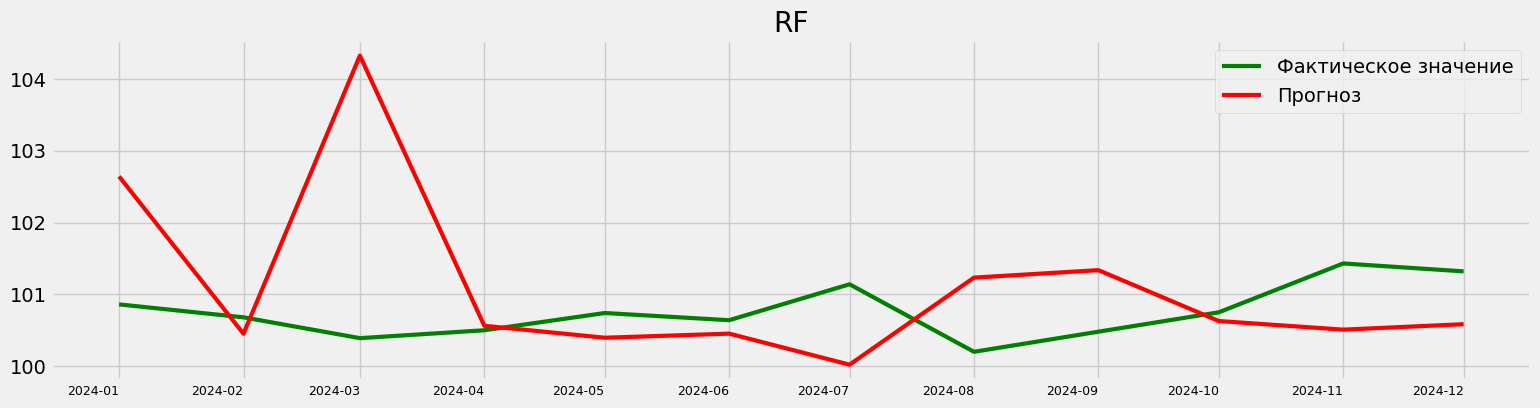

In [12]:
print(get_metrics(y_test, results_1)) # Вывод метрик качества модели на тестовой выборке
draw_result(y_test, results_1, 'RF') # Построение графика сравнения фактических и прогнозных значений

# Random Forest

In [13]:
%%time

n = 12 # Горизонт прогнозирования (12 периодов)

y_train = y[12:-(n)] # Целевая переменная для обучения (пропускаем первые 12 наблюдений)
    
X_train = lagged_df[:-(n)] # Признаки для обучения (все кроме последних n периодов)
    
y_test = y[-(n):] # Целевая переменная для тестирования (последние n периодов)
    
X_test = lagged_df[-(n):] # Признаки для тестирования (последние n периодов)

# Создание конвейера обработки данных и модели    
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()), # Стандартизация признаков
    ('feature_selection', RFE(estimator=RandomForestRegressor(random_state=42))), # Рекурсивное исключение признаков
    ('classifier', RandomForestRegressor(bootstrap=True)) # Модель случайного леса
])

# Сетка гиперпараметров для подбора
param_grid_rf = {
'classifier__n_estimators': [100, 300, 500], # Количество деревьев
'classifier__max_depth': [3, 5, 7, 10], # Максимальная глубина дерева
'classifier__min_samples_split': [2, 3, 5, 8], # Минимальное количество выборок для разбиения узла
'classifier__min_samples_leaf': [2, 3, 5, 8], # Минимальное количество выборок в листовом узле
'classifier__max_features': [2, 4,  6, 7, 8, 10], # Количество признаков для рассмотрения при разбиении
}

# Настройка поиска по сетке гиперпараметров
grid_search_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid_rf,
    cv=2,                                             # 2-кратная кросс-валидация
    scoring='neg_mean_absolute_error',                # Метрика: MAE
    verbose=2,                                        # Отображение прогресса
    n_jobs=-1                                         # Использование всех доступных процессоров
)

grid_search_rf.fit(X_train, y_train) # Запуск поиска лучших гиперпараметров

pred = grid_search_rf.predict(X_test) # Прогнозирование на тестовой выборке
    
results_2 = pred # Сохранение результатов

best_pipeline_rf = grid_search_rf.best_estimator_ # Лучшая найденная конвейер-модель
rfe_step_rf = best_pipeline_rf.named_steps['feature_selection'] # Этап отбора признаков
selected_features_mask_rf = rfe_step_rf.support_ # Маска отобранных признаков
selected_features_rf = X_train.columns[selected_features_mask_rf] # Названия отобранных признаков

print("Отобранные признаки RFE:", selected_features_rf)
print()
print("Лучшие параметры:", grid_search_rf.best_params_)
print()
print("Лучший MAE (на обучающей выборке):", round(-grid_search_rf.best_score_, 2))
print()
#     print(f'RMSE на тесте: {}')
print(f'MAE на тесте: {round(mean_absolute_error(y_test, results_2),2)}')
print()
print("Прогноз:", results_2)
print()

Fitting 2 folds for each of 1152 candidates, totalling 2304 fits
Отобранные признаки RFE: Index(['ИПП_РФ_lag_12', 'Обработка_РФ_lag_12',
       'Индикатор_бизнес-климата_РФ_lag_12', 'USD_lag_12', 'Ипотека_РФ_lag_12',
       'Средства_населения_РФ_lag_12'],
      dtype='object')

Лучшие параметры: {'classifier__max_depth': 3, 'classifier__max_features': 2, 'classifier__min_samples_leaf': 5, 'classifier__min_samples_split': 8, 'classifier__n_estimators': 100}

Лучший MAE (на обучающей выборке): 0.37

MAE на тесте: 0.36

Прогноз: [101.05046757 100.36018926 101.19487584 100.61144413 100.67121597
 100.69886197 100.56169189 100.69298901 100.69331367 100.68096392
 100.60656551 100.73123451]

CPU times: total: 10.1 s
Wall time: 6min 9s


RMSE: 0.453, MAE: 0.36


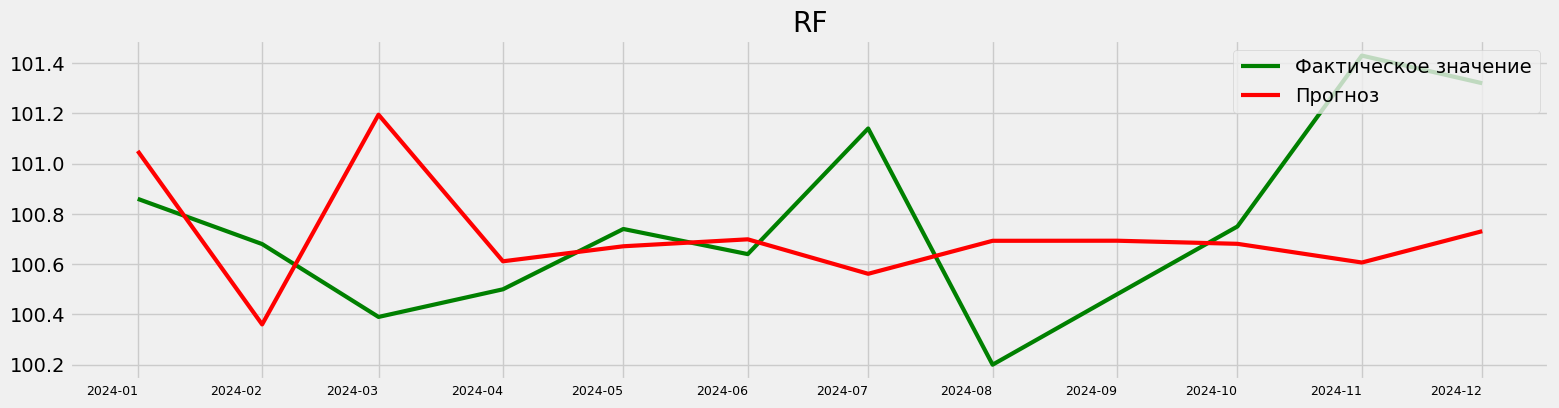

In [14]:
print(get_metrics(y_test, results_2))
draw_result(y_test, results_2, 'RF')